Cell 1 — Imports and Load Results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, RocCurveDisplay,
    PrecisionRecallDisplay, classification_report
)
import shap

BASE     = Path(r'C:\Users\Owner\OneDrive\dissertation')
DATA_DIR = BASE / 'data' / 'processed'
FIG_DIR  = BASE / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Load saved results
results_df  = pd.read_csv(DATA_DIR / 'model_results.csv')
shap_df     = pd.read_csv(DATA_DIR / 'shap_values.csv')

print(results_df)
print(f'\nSHAP values shape: {shap_df.shape}')

            Unnamed: 0     AUROC     AUPRC
0  Logistic Regression  0.651757  0.061108
1        Random Forest  0.686901  0.161140
2              XGBoost  0.646326  0.103293

SHAP values shape: (323, 13)


Cell 2 — Results Summary Table:

In [5]:
# === CELL 2: Results Summary Table ===

# Fix column name
results_df = results_df.rename(columns={'Unnamed: 0': 'Model'})

baseline = 10 / 323  # crisis rate

print('=' * 55)
print(f'{"Model":<25} {"AUROC":>8} {"AUPRC":>8} {"AUPRC/Base":>10}')
print('-' * 55)
for _, row in results_df.iterrows():
    lift = row['AUPRC'] / baseline
    print(f'{row["Model"]:<25} {row["AUROC"]:>8.4f} {row["AUPRC"]:>8.4f} {lift:>9.1f}x')
print('=' * 55)
print(f'Baseline AUPRC (random): {baseline:.4f} ({100*baseline:.1f}%)')

Model                        AUROC    AUPRC AUPRC/Base
-------------------------------------------------------
Logistic Regression         0.6518   0.0611       2.0x
Random Forest               0.6869   0.1611       5.2x
XGBoost                     0.6463   0.1033       3.3x
Baseline AUPRC (random): 0.0310 (3.1%)


In [13]:
print(f"X shape: {X.shape}")
print(f"X first row: {X.iloc[0].values}")
print(f"y sum: {y.sum()}")

X shape: (414, 13)
X first row: [ 9.76053332e-02  1.02579024e-01  7.73497105e-02  7.44746045e-01
  5.63543819e-02  1.17374557e+02  2.03779498e+04 -2.09510833e-02
 -4.63062083e-02 -2.53552917e-02 -3.68936957e-02 -5.32321304e-02
 -1.63386087e-02]
y sum: 13.0


Cell 3 — Precision-ARecall Curves:

X shape: (323, 13) | Crisis events: 10
Running CV: Logistic Regression ...
Running CV: Random Forest ...
Running CV: XGBoost ...


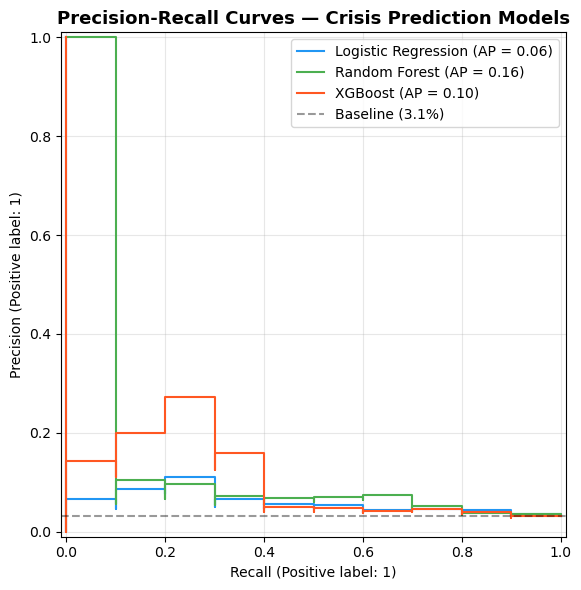

Saved → pr_curves.png


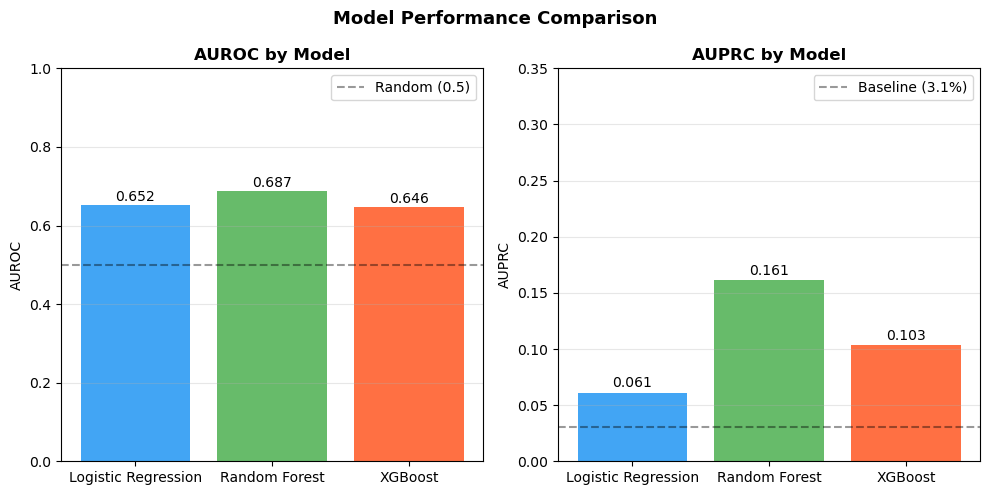

Saved → performance_comparison.png


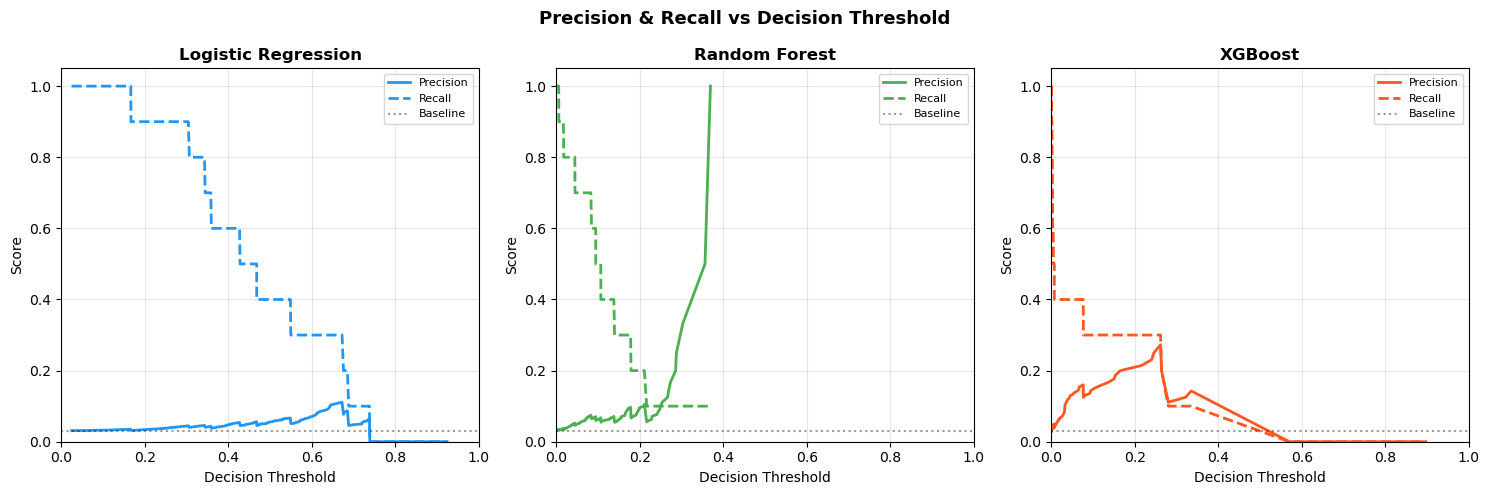

Saved → threshold_analysis.png


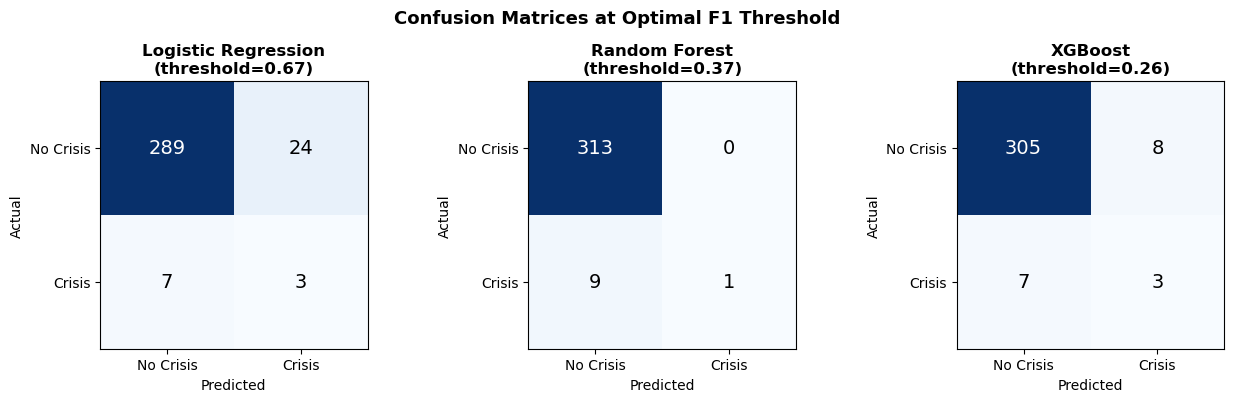

Saved → confusion_matrices.png


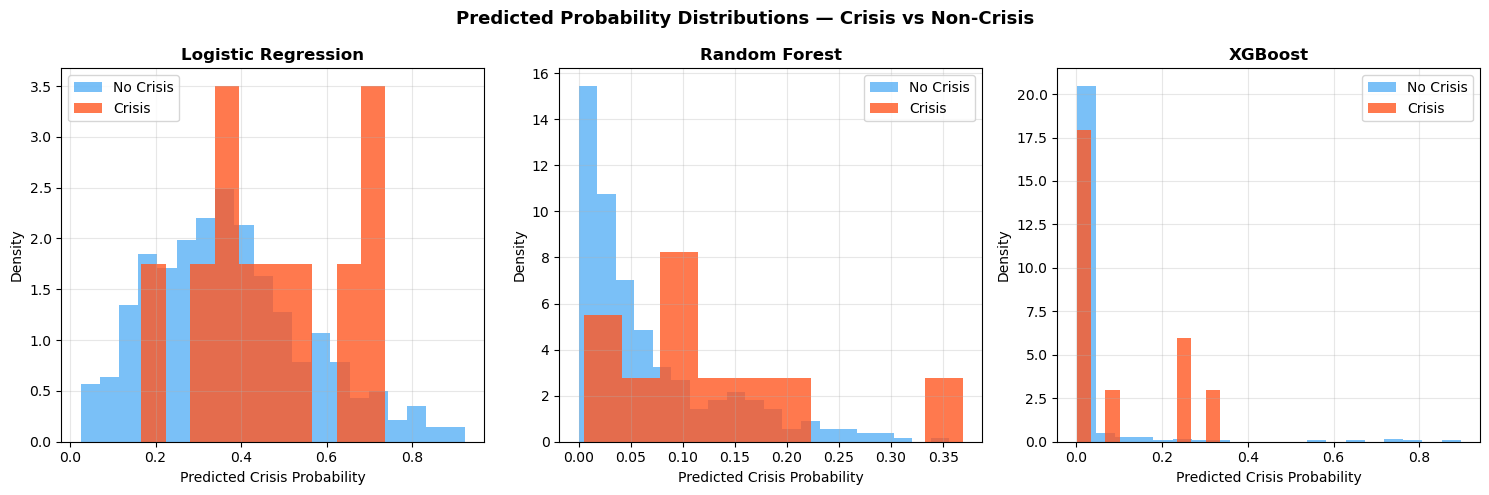

Saved → prob_distributions.png

✓ All 5 charts saved to C:\Users\Owner\OneDrive\dissertation\figures


In [15]:
# === CELL 3: PR Curves + Supporting Visualisations ===

from sklearn.metrics import precision_recall_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score, PrecisionRecallDisplay
import xgboost as xgb

# Load exact same X and y as Notebook 05
df_model2    = pd.read_csv(DATA_DIR / 'df_model_final.csv')
ALL_FEATURES = [c for c in df_model2.columns if c not in ['crisisjst', 'year', 'iso']]
X = df_model2[ALL_FEATURES]
y = df_model2['crisisjst']
print(f'X shape: {X.shape} | Crisis events: {int(y.sum())}')

MACRO_FEATURES_ENG     = ['tloans_gr', 'tmort_gr', 'money_gr', 'ca_gr', 'tloans_rgdp_gr', 'cpi', 'rgdpmad']
SENTIMENT_FEATURES_ENG = ['net_sentiment_dm', 'P_pos_dm', 'P_neg_dm']
LAG_FEATURES_ENG       = ['net_sentiment_lag1_dm', 'P_pos_lag1_dm', 'P_neg_lag1_dm']

RANDOM_STATE = 42
CV_FOLDS     = 5
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                   random_state=RANDOM_STATE, C=0.1))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, max_depth=5, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        base_score=0.5, scale_pos_weight=(y==0).sum()/(y==1).sum(),
        random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
}

probs = {}
for name, model in models.items():
    print(f'Running CV: {name} ...')
    probs[name] = cross_val_predict(model, X, y, cv=cv,
                                     method='predict_proba', n_jobs=-1)[:, 1]

colors   = {'Logistic Regression': '#2196F3',
            'Random Forest':       '#4CAF50',
            'XGBoost':             '#FF5722'}
baseline = y.mean()

# ── CHART 1: Precision-Recall Curves ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
for name, y_prob in probs.items():
    PrecisionRecallDisplay.from_predictions(
        y, y_prob, name=name, ax=ax, color=colors[name])
ax.axhline(y=baseline, color='k', linestyle='--', alpha=0.4,
           label=f'Baseline ({100*baseline:.1f}%)')
ax.set_title('Precision-Recall Curves — Crisis Prediction Models',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'pr_curves.png', dpi=150)
plt.show()
print('Saved → pr_curves.png')

# ── CHART 2: AUROC & AUPRC Bar Chart ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
model_names = list(probs.keys())
aurocs = [roc_auc_score(y, probs[m]) for m in model_names]
auprcs = [average_precision_score(y, probs[m]) for m in model_names]
bar_colors = [colors[m] for m in model_names]

axes[0].bar(model_names, aurocs, color=bar_colors, alpha=0.85)
axes[0].axhline(0.5, color='k', linestyle='--', alpha=0.4, label='Random (0.5)')
axes[0].set_ylim(0, 1)
axes[0].set_title('AUROC by Model', fontweight='bold')
axes[0].set_ylabel('AUROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(aurocs):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(model_names, auprcs, color=bar_colors, alpha=0.85)
axes[1].axhline(baseline, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline ({100*baseline:.1f}%)')
axes[1].set_ylim(0, 0.35)
axes[1].set_title('AUPRC by Model', fontweight='bold')
axes[1].set_ylabel('AUPRC')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(auprcs):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'performance_comparison.png', dpi=150)
plt.show()
print('Saved → performance_comparison.png')

# ── CHART 3: Threshold Analysis ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_prob) in zip(axes, probs.items()):
    prec, rec, thresh = precision_recall_curve(y, y_prob)
    ax.plot(thresh, prec[:-1], color=colors[name], linewidth=2, label='Precision')
    ax.plot(thresh, rec[:-1],  color=colors[name], linewidth=2,
            linestyle='--', label='Recall')
    ax.axhline(baseline, color='k', linestyle=':', alpha=0.4, label='Baseline')
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Score')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
plt.suptitle('Precision & Recall vs Decision Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'threshold_analysis.png', dpi=150)
plt.show()
print('Saved → threshold_analysis.png')

# ── CHART 4: Confusion Matrices at Optimal F1 Threshold ───────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, y_prob) in zip(axes, probs.items()):
    prec, rec, thresh = precision_recall_curve(y, y_prob)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    opt_thresh = thresh[np.argmax(f1)]
    y_pred = (y_prob >= opt_thresh).astype(int)
    cm = confusion_matrix(y, y_pred)
    ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['No Crisis', 'Crisis'])
    ax.set_yticklabels(['No Crisis', 'Crisis'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name}\n(threshold={opt_thresh:.2f})', fontweight='bold')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.suptitle('Confusion Matrices at Optimal F1 Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'confusion_matrices.png', dpi=150)
plt.show()
print('Saved → confusion_matrices.png')

# ── CHART 5: Predicted Probability Distributions ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, y_prob) in zip(axes, probs.items()):
    crisis    = y_prob[y == 1]
    no_crisis = y_prob[y == 0]
    ax.hist(no_crisis, bins=20, alpha=0.6, color='#2196F3',
            label='No Crisis', density=True)
    ax.hist(crisis,    bins=10, alpha=0.8, color='#FF5722',
            label='Crisis',    density=True)
    ax.set_xlabel('Predicted Crisis Probability')
    ax.set_ylabel('Density')
    ax.set_title(name, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Predicted Probability Distributions — Crisis vs Non-Crisis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'prob_distributions.png', dpi=150)
plt.show()
print('Saved → prob_distributions.png')

print(f'\n✓ All 5 charts saved to {FIG_DIR}')

Cell 4 — SHAP Dependence Plots:

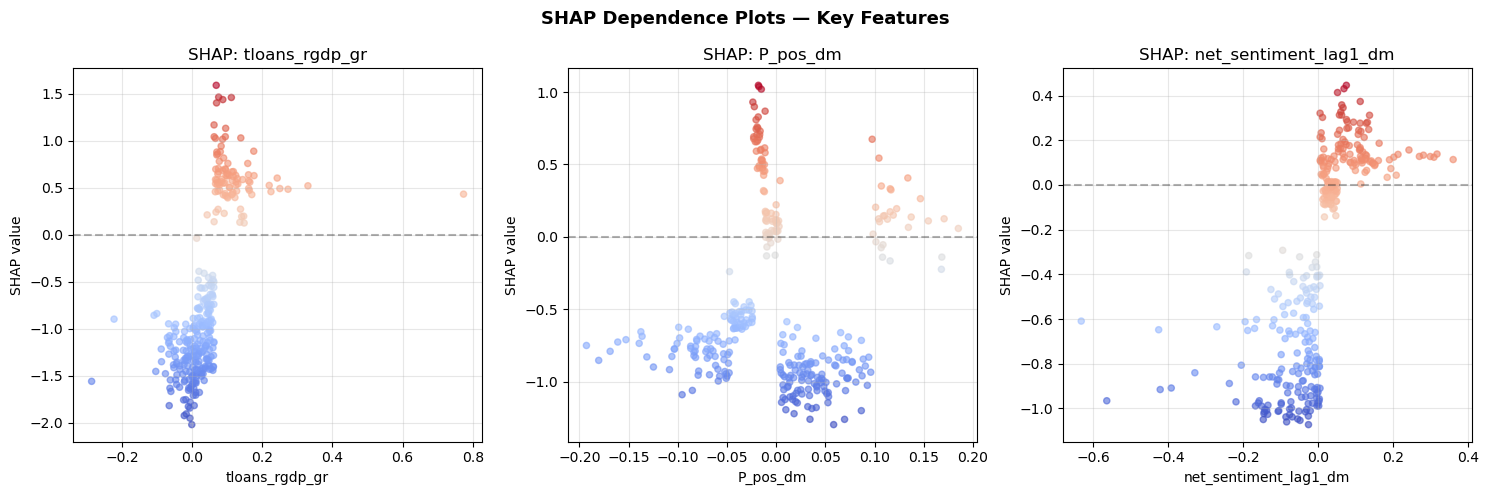

Saved → C:\Users\Owner\OneDrive\dissertation\figures/shap_dependence.png


In [17]:
# Refit XGBoost on full data for SHAP
import tempfile, os
xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    base_score=0.5, scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
xgb_model.fit(X, y)
tmp = tempfile.mktemp(suffix='.json')
xgb_model.save_model(tmp)
xgb_model.load_model(tmp)
os.remove(tmp)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

# Dependence plots for top features
top_features = ['tloans_rgdp_gr', 'P_pos_dm', 'net_sentiment_lag1_dm']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, feat in zip(axes, top_features):
    feat_idx = ALL_FEATURES.index(feat)
    ax.scatter(X[feat], shap_values[:, feat_idx],
               c=shap_values[:, feat_idx], cmap='coolwarm',
               alpha=0.6, s=20)
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('SHAP value')
    ax.set_title(f'SHAP: {feat}')
    ax.grid(True, alpha=0.3)
plt.suptitle('SHAP Dependence Plots — Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_dependence.png', dpi=150)
plt.show()
print(f'Saved → {FIG_DIR}/shap_dependence.png')

Cell 5 — Temporal Analysis:

df_temp rows: 323 | probs length: 323


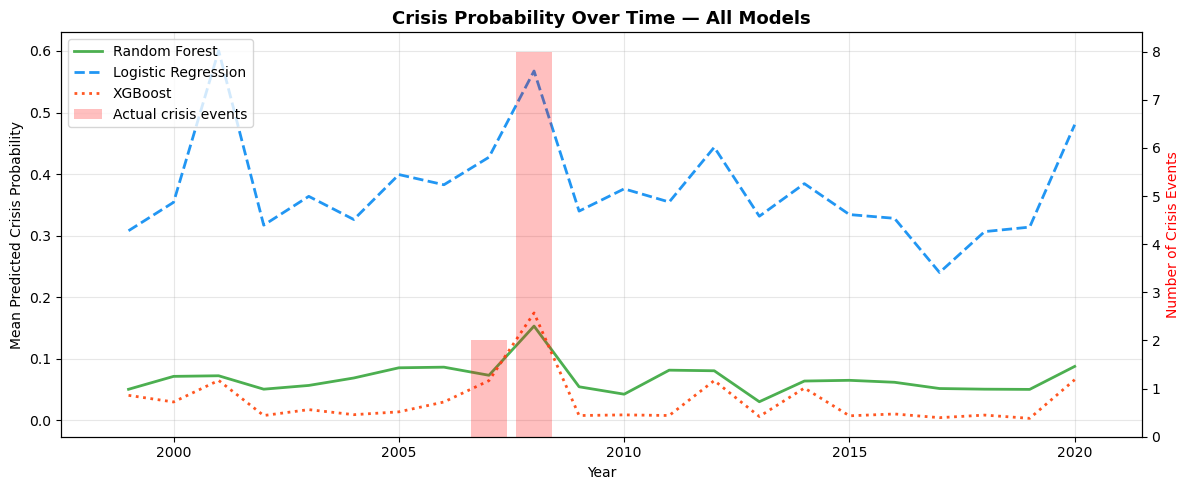

Saved → C:\Users\Owner\OneDrive\dissertation\figures/temporal_analysis.png


In [27]:
# === CELL 5: Temporal Analysis ===

# Reload directly to guarantee 323 rows
df_temp = pd.read_csv(DATA_DIR / 'df_model_final.csv').reset_index(drop=True)
print(f'df_temp rows: {len(df_temp)} | probs length: {len(probs["Random Forest"])}')

df_temp['rf_prob']  = probs['Random Forest']
df_temp['lr_prob']  = probs['Logistic Regression']
df_temp['xgb_prob'] = probs['XGBoost']

yearly = df_temp.groupby('year').agg(
    rf_prob=('rf_prob', 'mean'),
    lr_prob=('lr_prob', 'mean'),
    xgb_prob=('xgb_prob', 'mean'),
    actual_crises=('crisisjst', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(yearly['year'], yearly['rf_prob'],  color='#4CAF50',
         linewidth=2, label='Random Forest')
ax1.plot(yearly['year'], yearly['lr_prob'],  color='#2196F3',
         linewidth=2, label='Logistic Regression', linestyle='--')
ax1.plot(yearly['year'], yearly['xgb_prob'], color='#FF5722',
         linewidth=2, label='XGBoost', linestyle=':')
ax2.bar(yearly['year'], yearly['actual_crises'], alpha=0.25,
        color='red', label='Actual crisis events')

ax1.set_xlabel('Year')
ax1.set_ylabel('Mean Predicted Crisis Probability')
ax2.set_ylabel('Number of Crisis Events', color='red')
ax1.set_title('Crisis Probability Over Time — All Models',
              fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'temporal_analysis.png', dpi=150)
plt.show()
print(f'Saved → {FIG_DIR}/temporal_analysis.png')

Cell 6 — Final Summary:

In [29]:
print('=' * 60)
print(' NOTEBOOK 06 COMPLETE — Results Analysis')
print('=' * 60)
print('\nFigures generated:')
for f in ['pr_curves.png', 'shap_dependence.png', 'temporal_analysis.png']:
    print(f'  ✓ {f}')
print('\nReady to proceed to dissertation write-up.')

 NOTEBOOK 06 COMPLETE — Results Analysis

Figures generated:
  ✓ pr_curves.png
  ✓ shap_dependence.png
  ✓ temporal_analysis.png

Ready to proceed to dissertation write-up.
